# MTH 4224 / CSE 4224 - Python Assignment

The goal is to get comfortable writing Python (loops, if, lists/dicts, functions, classes), and using the common libraries commonly used in ML (NumPy / pandas / matplotlib).

**Deadline**: Jan 24, 2026

**Points**: 40

**Academic Honesty**: Write your code from scratch. You can learn from the documentation, the internet, and talk through ideas, but don't copy-paste solution blocks. Your notebook should look like *your* work.

## Instructions

Submit one Jupyter notebook (.ipynb). It must include:

* Mathematical work (typed or photos of handwritten work), if applicable (submit pictures with the notebook if needed.)

* Text explanations

* Well-commented code (every few lines)

* Outputs (tables/prints/plots)

Do not submit compressed files like zip, rar, etc. 


## Problem 1 — Random Walk Simulation and Empirical Exploration (15 points)

### Background: What is a Random Walk?

A **one-dimensional random walk** is a simple process that evolves step-by-step along a number line.

We start at position $S_0 = 0$.  
At each step, the walker moves:

- one unit to the right ($+1$), or  
- one unit to the left ($-1$).

In this assignment, the probability of stepping right is $p$, and the probability of stepping left is $1-p$.

After $N$ steps, the walk produces a sequence of positions

$$
S_0, S_1, S_2, \dots, S_N,
$$

where $S_n$ is the position after $n$ steps.

Even though the rules are simple, random walks display rich behavior that we can explore using simulation and visualization.

### Part A — Random walk class (10 points)

Design a Python class `RandomWalk1D` with the following functionality:

- An initialization method `__init__` that sets:
  - step probability $p$ of moving $+1$ (and $-1$ with probability $1-p$),  
  - number of steps $N$,  
  - optional random seed.

- Simulation methods:
  - `simulate_one()` returns the entire walk path $(S_0,\dots,S_N)$.  
  - `simulate_many(M)` simulates $M$ independent walks and returns all paths in a NumPy array or pandas DataFrame.  
  Your multi-walk simulation should be reasonably vectorized.

- Summary methods to compute:
  - average final position over many walks  
  - spread (variance or standard deviation) of final positions  
  - first hitting time to a boundary  

### Part B — Empirical experiments (5 points)

Use your simulator to investigate the following. No probability theory is required — focus on experimentation, plots, and interpretation.

**Experiment 1: Effect of step bias**

- Fix $N=500$.  
- Run simulations for $p = 0.50$ and $p = 0.55$.  
- Plot several sample paths.
- Compare the average final position in each case.  
- Briefly describe what changes when $p$ is increased.

**Experiment 2: Spread vs number of steps**

- Fix $p=0.5$.  
- Run simulations for $N \in \{100, 200, ..., 1000\}$.  
- Estimate the standard deviation of final positions for each $N$.  
- Make a plot of mean final positions vs $N$ with box-and-whisker plots at each point.
- Briefly describe how the spread grows as $N$ increases.

**Experiment 3: First hitting time**

Let $\tau_a$ be the first time the walk reaches either $+a$ or $-a$.

- Fix $p=0.5$ and simulate for $a \in \{1, 2, ..., 50\}$.  
- Estimate the average hitting time for each $a$.  
- Make a plot of average hitting time vs $a$ with box-and-whisker plots at each point.  
- Briefly describe the relationship you observe.

**Deliverables for Problem 1**

- Class implementation  
- Plots for each experiment  
- Short written interpretation (1-2 sentences each)

### Additional Requirement for Graduate-Credit Students

Students enrolled for graduate credit by arrangement must complete the following extension.  
All other students may complete this for bonus credit.

#### Continuous-Step Random Walk Extension (+5 points)

Modify your `RandomWalk1D` class so that step sizes are **random magnitudes** instead of fixed ±1 steps.

The walk now evolves according to

$$
S_{n+1} = S_n + \Delta_n,
$$

where each step increment is drawn from a normal distribution

$$
\Delta_n \sim \mathcal{N}(\mu, \sigma^2).
$$

Tasks:

- Replace the step-probability parameter $p$ with parameters $\mu$ and $\sigma$.  
- Implement simulation methods using NumPy’s normal random number generator.  
- Repeat Experiments 1–3 from Part B using at least two different $(\mu,\sigma)$ settings.  
- Briefly discuss how changing $\mu$ and $\sigma$ affects the behavior of the walk.


## Part A — RandomWalk1D Class

#### Math Setup (Random Walk)

We define a 1D random walk by:

- Start at \(S_0 = 0\)
- At each step:
  - move +1 with probability \(p\)
  - move -1 with probability \(1-p\)

The path is \(S_0, S_1, ..., S_N\).


In [2]:
import numpy as np
import pandas as pd

class RandomWalk1D:

    def __init__(self, p=0.5, N=100, seed=None):
        self.p = p
        self.N = N
        self.seed = seed

        self.rng = np.random.default_rng(seed)


    # Simulation Methods
    def simulate_one(self):
        """
        Simulates one random walk
        """
        steps = self.rng.choice([1, -1], size=self.N, p=[self.p, 1 - self.p])
        positions = np.cumsum(steps)
        path = np.insert(positions, 0, 0)

        return path


    def simulate_many(self, M, return_data=False):
        """
        Simulates M independent walks.
        """
        steps = self.rng.choice([1, -1], size=(M, self.N), p=[self.p, 1 - self.p])

        # Step 1...N
        positions = np.cumsum(steps, axis=1)
        paths = np.hstack([np.zeros((M, 1), dtype=int), positions])

        if return_data:
            return pd.DataFrame(paths, columns=[f"S{t}" for t in range(self.N + 1)])
        else:
            return paths


    def average_final_position(self, M):
        """
        Computes the average final position over M simulated walks.
        """
        paths = self.simulate_many(M)
        final_positions = paths[:, -1]
        return np.mean(final_positions)


    def final_spread(self, M, method="std"):
        """
        Computes the spread of final positions over M walks.
        """
        paths = self.simulate_many(M)
        final_positions = paths[:, -1]

        if method == "std":
            return np.std(final_positions)
        elif method == "var":
            return np.var(final_positions)
        

    def first_hitting_time(self, M, boundary):
        """
        Computes the first hitting time to a boundary for each walk.
        """
        paths = self.simulate_many(M)

        if isinstance(boundary, tuple):
            lower, upper = boundary
            hit_mask = (paths <= lower) | (paths >= upper)
        else:
            b = boundary
            hit_mask = (paths <= -b) | (paths >= b)

        hit_times = np.full(M, self.N + 1, dtype=int)
    
        for i in range(M):
            hits = np.where(hit_mask[i])[0]
            if len(hits) > 0:
                hit_times[i] = hits[0]

        return hit_times


## Part B — Empirical Experiments

### Experiment 1: Effect of Step Bias

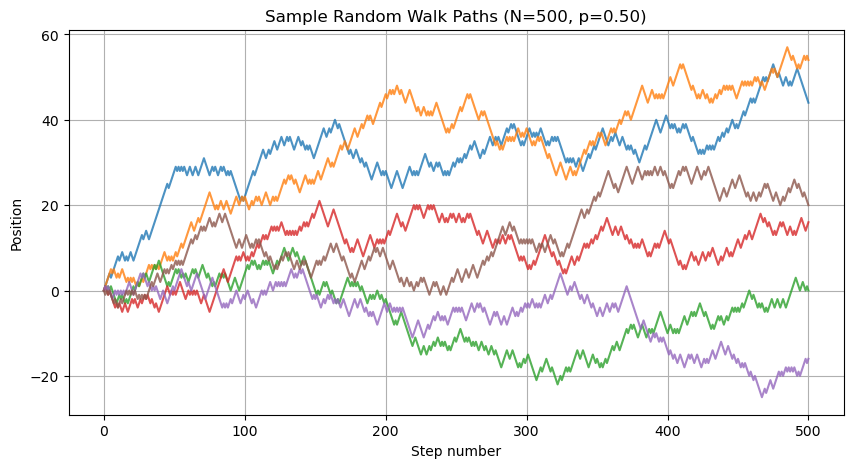

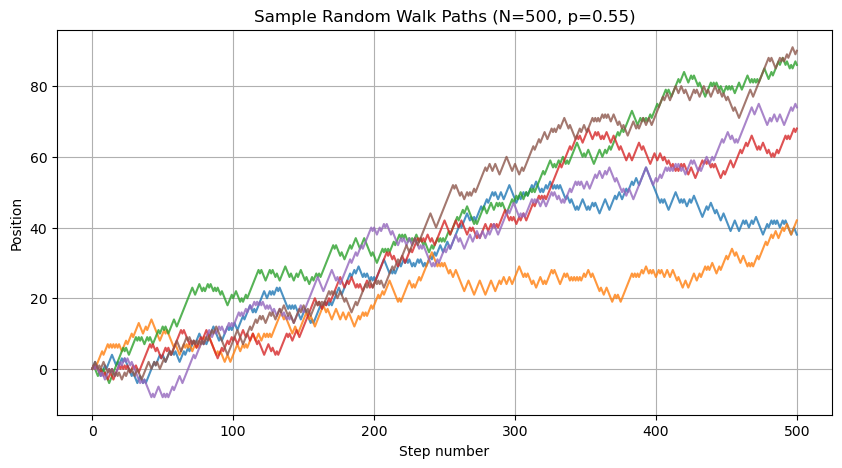

Average final position for when the probability of moving +1 is 0.50 (M=5000): 0.080
Average final position for when the probability of moving +1 is 0.55 (M=5000): 49.776


In [19]:
import matplotlib.pyplot as plt

N = 500
num_paths = 6
M = 5000 


unbiased = RandomWalk1D(p=0.50, N=N)
biased = RandomWalk1D(p=0.55, N=N)

# sample paths
plt.figure(figsize=(10, 5))
for _ in range(num_paths):
    path = unbiased.simulate_one()
    plt.plot(path, alpha=0.8)

plt.title("Sample Random Walk Paths (N=500, p=0.50)")
plt.xlabel("Step number")
plt.ylabel("Position")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
for _ in range(num_paths):
    path = biased.simulate_one()
    plt.plot(path, alpha=0.8)

plt.title("Sample Random Walk Paths (N=500, p=0.55)")
plt.xlabel("Step number")
plt.ylabel("Position")
plt.grid(True)
plt.show()

# Compare average final position
avg_final_unbiased = unbiased.average_final_position(M)
avg_final_biased = biased.average_final_position(M)

print(f"Average final position for when the probability of moving +1 is 0.50 (M={M}): {avg_final_unbiased:.3f}")
print(f"Average final position for when the probability of moving +1 is 0.55 (M={M}): {avg_final_biased:.3f}")


#### Interpretation

When p = 0.50, the random walk is symmetric and tends to hover around 0, with final positions centered near zero. When p = 0.55, the random walk is leaned to the right, so paths tend to trend upward, causing final positions to be noticeably larger on average. Even with randomness, the biased walk is much more likely to end on the positive side compared to the unbiased case.

### Experiment 2: Spread vs number of steps

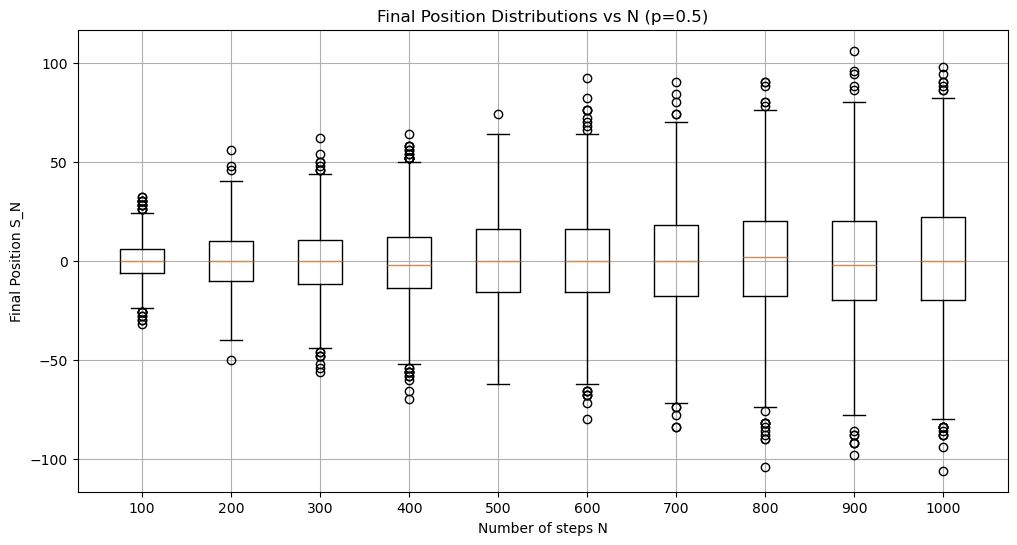

N	Mean Final	Std Dev
100	0.511		9.834
200	0.177		14.298
300	-0.258		17.234
400	-0.500		20.211
500	-0.262		22.881
600	-0.002		24.305
700	0.235		26.317
800	0.567		28.667
900	-0.322		29.963
1000	0.545		31.686


In [4]:
N_values = list(range(100, 1001, 100))
final_positions_list = []
stds = []
means = []

for N in N_values:
    rw = RandomWalk1D(p=0.5, N=N)
    paths = rw.simulate_many(2000)
    finals = paths[:, -1]
    
    final_positions_list.append(finals)
    stds.append(np.std(finals))
    means.append(np.mean(finals))

# Boxplot of final positions
plt.figure(figsize=(12, 6))
plt.boxplot(final_positions_list, positions=N_values, widths=50)
plt.title("Final Position Distributions vs N (p=0.5)")
plt.xlabel("Number of steps N")
plt.ylabel("Final Position S_N")
plt.grid(True)
plt.show()


print("N\tMean Final\tStd Dev")
for i in range(len(N_values)):
    print(f"{N_values[i]}\t{means[i]:.3f}\t\t{stds[i]:.3f}")


#### Interpretation

The spread increases as N increases, meaning as N increases the results become more uncertain. The standard deviation grows gradually, showing that longer walks have more room to drift far away from 0 in either direction.

### Experiment 3: First hitting time

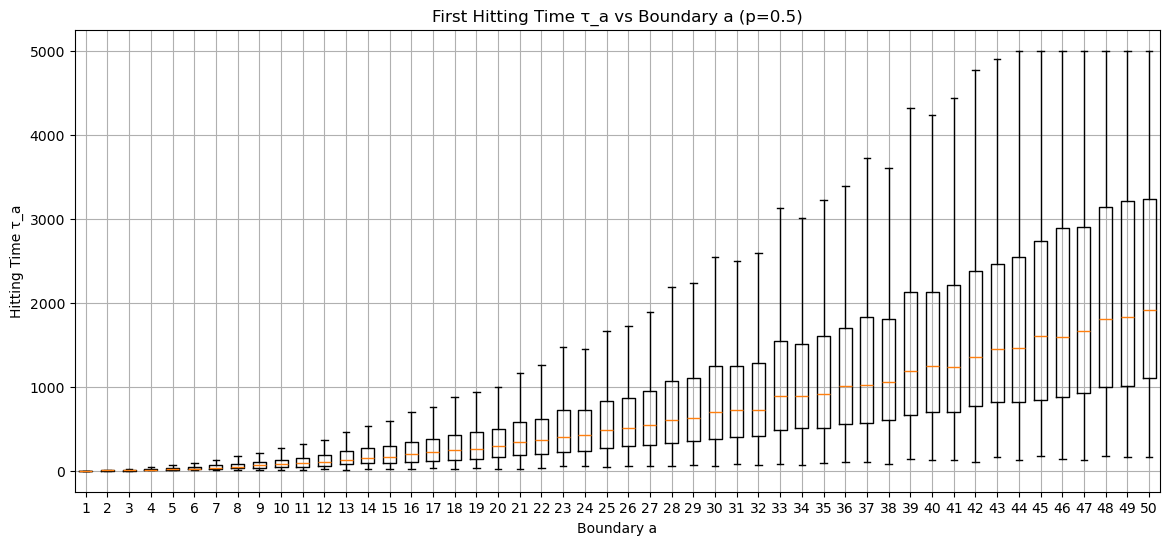

In [5]:
a_values = list(range(1, 51))
hit_list = []
hit_means = []

rw = RandomWalk1D(p=0.5, N=5000)

for a in a_values:
    hit_times = rw.first_hitting_time(M = 1500, boundary=a)
    hit_list.append(hit_times)
    hit_means.append(np.mean(hit_times))

# Boxplot of hitting times
plt.figure(figsize=(14, 6))
plt.boxplot(hit_list, positions = a_values, widths = 0.6, showfliers=False)
plt.title("First Hitting Time τ_a vs Boundary a (p=0.5)")
plt.xlabel("Boundary a")
plt.ylabel("Hitting Time τ_a")
plt.grid(True)
plt.show()



#### Interpretation

As a increases, the walk takes longer on average to reach ±a.The increase is not linear as hitting larger boundaries becomes alot harder as distance grows. The boxplots also widen, showing that hitting time becomes more variable for larger a values.

## Problem 2 — Regression on Real Data: Bike Sharing (25 points)

In this problem you will work with a real dataset and implement linear regression methods from scratch using NumPy and pandas with the **Bike Sharing Dataset** (https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset)

A key goal of this problem is to practice writing code in a clean, reusable, object-oriented style similar to `scikit-learn`.

### Part A — Loading, cleaning, and feature engineering (10 points)

- Load the dataset into pandas.  
- Construct a feature matrix $X$ and label vector $y$, where $y$ is the total number of rentals.  
- Handle missing values and explain your choices.  
- Parse date/time fields (if present) and extract useful features such as hour, day-of-week, or month.  
- Encode categorical variables appropriately.

Your final $X$ should be entirely numerical and ready for matrix calculations.

### Part B — Ordinary Least Squares Class Implementation (5 points)

In class we derived the closed-form solution for ordinary least squares (the **normal equations**). Here you will implement OLS inside a class with a `scikit-learn`–style interface.

Design a class `LinearRegressionOLS` with the following methods:

- `fit(X, y)`  
  Computes and stores the parameter vector $\hat{\theta}_{OLS}$ using NumPy matrix operations.

- `predict(X)`  
  Returns predicted values $\hat{y}$ for input feature matrix $X$.

Tasks:

- Split the dataset randomly into 80\% training and 20\% test data.  
- Call `fit` on the training set.  
- Use `predict` on both training and test sets.  
- Report training and test MSE and $R^2$.  
- Report approximate runtime for training and inference using `time.perf_counter()`.

### Part C — Weighted Least Squares: Math and Class Implementation (10 points)

You will now derive and implement **Weighted Least Squares (WLS)** inside a scikit-learn–style class.

Define a diagonal weight matrix $W = \mathrm{diag}(w_1,\dots,w_n)$ with $w_i > 0$. WLS minimizes the loss function

$$
L(\theta) = (y - X\theta)^T W (y - X\theta).
$$

#### Math task

- Compute $\nabla_\theta L(\theta)$.  
- Set the gradient equal to zero and solve for $\theta$.  
- Write your final answer in closed form.

(Your solution should result in a matrix expression for $\hat{\theta}_{WLS}$.)

#### Implementation task

Design a class `LinearRegressionWLS` with the following methods:

- `fit(X, y, w)`  
  Computes and stores $\hat{\theta}_{WLS}$.  
  Here `w` is a vector containing the diagonal entries of $W$.

- `predict(X)`  
  Returns predicted values for input feature matrix $X$.

Additional requirements:

- Design a simple, clearly explained rule to choose the weights $w_i$.  
  (Example ideas: give more weight to recent data, to high-rental observations, or to underrepresented categories.)  
- Compare WLS against OLS on the test set using MSE and $R^2$.  
- Briefly discuss the effect of weighting.

#### Required plots

- Predicted vs actual scatter plots (test set, OLS and WLS).  
- Residual histograms (test set, OLS and WLS).

#### Runtime reporting

Using `time.perf_counter()`, report approximate runtime for:

- OLS training  
- OLS inference on the test set  
- WLS training  
- WLS inference on the test set  

### Additional Requirement for Graduate-Credit Students

Students enrolled for graduate credit must complete the following extension.  
Other students may complete this for bonus credit.

#### QR-Based Least Squares Class Implementation (+5 points)

In Part B, you implemented ordinary least squares using the normal equations.  
In practice, solving least squares problems via **QR factorization** is often more numerically stable.

The feature matrix $X$ can be factored as

$$
X = QR,
$$

where $Q$ has orthonormal columns ($Q^T Q = I$) and $R$ is upper triangular.

Using this factorization, the least-squares solution can be computed as

$$
\hat{\theta}_{QR} = R^{-1} Q^T y.
$$

Design a class `LinearRegressionQR` with the following methods:

- `fit(X, y)`  
  Uses `np.linalg.qr` to compute $Q$ and $R$, then stores $\hat{\theta}_{QR}$.

- `predict(X)`  
  Returns predicted values for input feature matrix $X$.

Tasks:

- Implement the QR-based least-squares solution inside the class.  
- Compare $\hat{\theta}_{QR}$ to $\hat{\theta}_{OLS}$.  
- Compare training runtime and inference runtime.  
- Briefly comment on any numerical differences you observe.

## Problem 2: Problem 2 — Regression on Real Data: Bike Sharing
### Part A: Loading, Cleaning, Feature Engineering

In [6]:
import pandas as pd
import numpy as np

FILE = "hour.csv"

data = pd.read_csv(FILE)


if "dteday" in data.columns:
    data["dteday"] = pd.to_datetime(data["dteday"])
    data["year"] = data["dteday"].dt.year
    data["month"] = data["dteday"].dt.month
    data["day"] = data["dteday"].dt.day
    data["day_of_week"] = data["dteday"].dt.dayofweek 
    

# y = total rentals
y = data["cnt"].values


drop_cols = ["cnt", "casual", "registered"]


if "dteday" in data.columns:
    drop_cols.append("dteday")


X_data = data.drop(columns=drop_cols)


# Fill missing values if they exist
for col in X_data.columns:
    if X_data[col].isna().sum() > 0:
        if np.issubdtype(X_data[col].dtype, np.number):
            X_data[col] = X_data[col].fillna(X_data[col].median())
        else:
            X_data[col] = X_data[col].fillna(X_data[col].mode()[0])


categorical_cols = ["season", "mnth", "weekday", "weathersit", "holiday", "workingday", "hr"]
categorical_cols = [c for c in categorical_cols if c in X_data.columns]


X_encoded = pd.get_dummies(X_data, columns=categorical_cols, drop_first=True)
X = X_encoded.values.astype(float)


I loaded the Bike Sharing dataset into pandas and used `cnt` (total rentals) as the label vector y.

If missing values existed:
- numeric columns were filled with the median
- categorical columns were filled with the mode
- This was handled in this way to not cause complications in data processing

From the `dteday` datetime column, I extracted:
- year, month, day, and day-of-week.

I removed casual and registered from the features because:
\[
cnt = casual + registered
\]

The final feature matrix \(X\) contains only the numeric values for matrix calculations.


## Part B — Ordinary Least Squares (OLS)

We model the relationship using the linear model:

$$
\hat{y} = X\theta
$$

OLS chooses parameters $\theta$ that minimize Mean Squared Error (MSE):

$$
J(\theta) = \frac{1}{n}\sum_{i=1}^n (y_i - \hat{y}_i)^2
$$

The closed-form OLS solution (Normal Equation) is:

$$
\theta_{OLS} = (X^T X)^{-1}X^T y
$$

To include an intercept (bias term), we augment $X$ with a column of ones.


In [7]:
import numpy as np
import time

np.random.seed()
n = X.shape[0]

# 80/20 split
indices = np.random.permutation(n)
split = int(0.8 * n)

train_idx = indices[:split]
test_idx = indices[split:]

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def r2_score(y_true, y_pred):
    # R² = 1 - (SS_res / SS_tot)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)


In [8]:
class LinearRegressionOLS:
    """
    Ordinary Least Squares Linear Regression using Normal Equation
    """

    def __init__(self):
        self.theta = None  

    def _add_intercept(self, X):
        """
        Adds a bias column of 1's to the left side of X.
        """
        ones = np.ones((X.shape[0], 1))
        return np.hstack([ones, X])

    def fit(self, X, y):
        """
        Computes theta using the normal equation:
        """
        X_bias = self._add_intercept(X)

        self.theta = np.linalg.pinv(X_bias.T @ X_bias) @ (X_bias.T @ y)

        return self

    def predict(self, X):
        """
        Predicts y-hat = X * theta
        """
        if self.theta is None:
            raise ValueError("Model has not been fitted yet.")

        X_bias = self._add_intercept(X)
        return X_bias @ self.theta


In [9]:
model = LinearRegressionOLS()

# Training
start_train = time.perf_counter()
model.fit(X_train, y_train)
end_train = time.perf_counter()

train_time = end_train - start_train

# Train predictions
begin_pred_train = time.perf_counter()
y_train_pred = model.predict(X_train)
end_pred_train = time.perf_counter()

total_train_time = end_pred_train - begin_pred_train

# Test predictions
begin_pred_test = time.perf_counter()
y_test_pred = model.predict(X_test)
end_pred_test = time.perf_counter()

total_test_time = end_pred_test - begin_pred_test

print("Training time (seconds):", train_time)
print("Train prediction time (seconds):", total_train_time)
print("Test prediction time (seconds):", total_test_time)


Training time (seconds): 0.04754940001294017
Train prediction time (seconds): 0.0034012000542134047
Test prediction time (seconds): 0.0011799000203609467


In [10]:
train_mse = mse(y_train, y_train_pred)
test_mse = mse(y_test, y_test_pred)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Train MSE: {train_mse:.3f}")
print(f"Test  MSE: {test_mse:.3f}")
print(f"Train R² : {train_r2:.3f}")
print(f"Test  R² : {test_r2:.3f}")

Train MSE: 10224.573
Test  MSE: 10588.787
Train R² : 0.690
Test  R² : 0.674


## Part C — Weighted Least Squares (WLS)

We define a diagonal weight matrix:

$$
W = \mathrm{diag}(w_1, w_2, \dots, w_n), \quad w_i > 0
$$

The WLS loss function is:

$$
L(\theta) = (y - X\theta)^T W (y - X\theta)
$$

### 1. Compute the gradient $ \nabla_\theta L(\theta) $

Expand the loss:

$$
L(\theta) = y^T W y - 2\theta^T X^T W y + \theta^T X^T W X \theta
$$

Differentiate with respect to $\theta$:

$$
\nabla_\theta L(\theta) = -2X^T W y + 2X^T W X\theta
$$

### 2. Set gradient equal to zero and solve

Set:

$$
-2X^T W y + 2X^T W X\theta = 0
$$

Divide by 2:

$$
X^T W X\theta = X^T W y
$$

### 3. Closed-form solution (WLS Normal Equation)

$$
\hat{\theta}_{WLS} = (X^T W X)^{-1} X^T W y
$$


In [11]:
class LinearRegressionWLS:
    """
    Weighted Least Squares Linear Regression 
    """

    def __init__(self):
        self.theta = None

    def _add_intercept(self, X):
        """Adds a bias column of 1's to X."""
        ones = np.ones((X.shape[0], 1))
        return np.hstack([ones, X])

    def fit(self, X, y, w):
        """
        Fits WLS model
        w is a length-n vector of weights (diagonal entries of W)
        """
        Xb = self._add_intercept(X)

        w = np.array(w).reshape(-1)

        # Weighted normal equation
        # X^T W X = X^T (w * X)
        a = Xb.T @ (w[:, None] * Xb)
        # X^T W y = X^T (w * y)
        b = Xb.T @ (w * y)

        self.theta = np.linalg.pinv(a) @ b
        return self

    def predict(self, X):
        """Predicts y_hat = X * theta"""
        Xb = self._add_intercept(X)
        return Xb @ self.theta


In [12]:
w_train = 1 + (y_train / np.max(y_train))
w_test = 1 + (y_test / np.max(y_test))

print("Train weights:\nmin =", w_train.min(), "\nmax =", w_train.max())


Train weights:
min = 1.0010235414534288 
max = 2.0


In [13]:
# Fit WLS
wls_model = LinearRegressionWLS()
wls_model.fit(X_train, y_train, w_train)

# Predict
y_train_pred_wls = wls_model.predict(X_train)
y_test_pred_wls = wls_model.predict(X_test)

# Metrics for WLS
train_mse_wls = mse(y_train, y_train_pred_wls)
test_mse_wls = mse(y_test, y_test_pred_wls)

train_r2_wls = r2_score(y_train, y_train_pred_wls)
test_r2_wls = r2_score(y_test, y_test_pred_wls)

print("WLS RESULTS")
print(f"Train MSE: {train_mse_wls:.3f}")
print(f"Test  MSE: {test_mse_wls:.3f}")
print(f"Train R² : {train_r2_wls:.4f}")
print(f"Test  R² : {test_r2_wls:.4f}")


WLS RESULTS
Train MSE: 10429.883
Test  MSE: 10752.726
Train R² : 0.6839
Test  R² : 0.6693


In [14]:
print("OLS vs WLS")
print(f"OLS Test MSE: {test_mse:.3f}")
print(f"WLS Test MSE: {test_mse_wls:.3f}")
print()
print(f"OLS Test R² : {test_r2:.4f}")
print(f"WLS Test R² : {test_r2_wls:.4f}")

OLS vs WLS
OLS Test MSE: 10588.787
WLS Test MSE: 10752.726

OLS Test R² : 0.6743
WLS Test R² : 0.6693


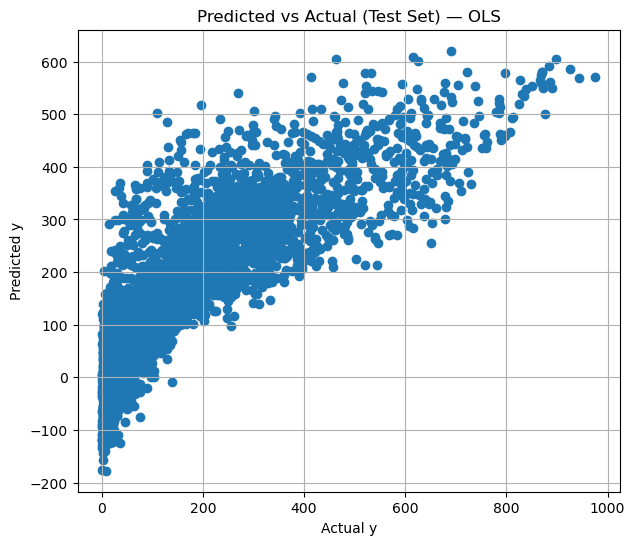

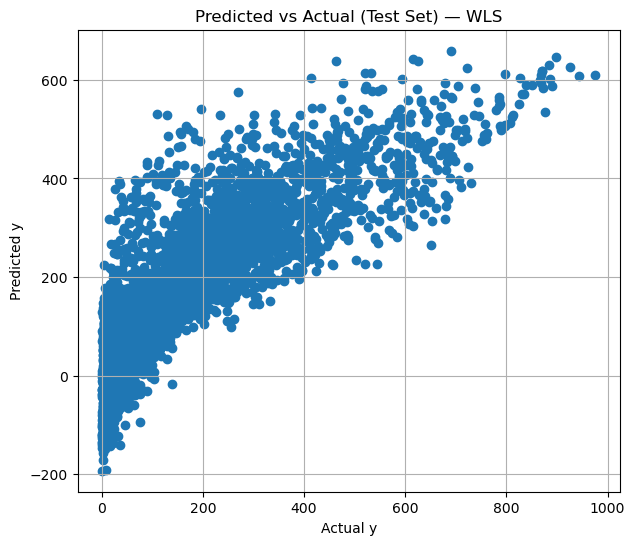

In [15]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_test_pred)
plt.title("Predicted vs Actual (Test Set) — OLS")
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_test_pred_wls)
plt.title("Predicted vs Actual (Test Set) — WLS")
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.grid(True)
plt.show()


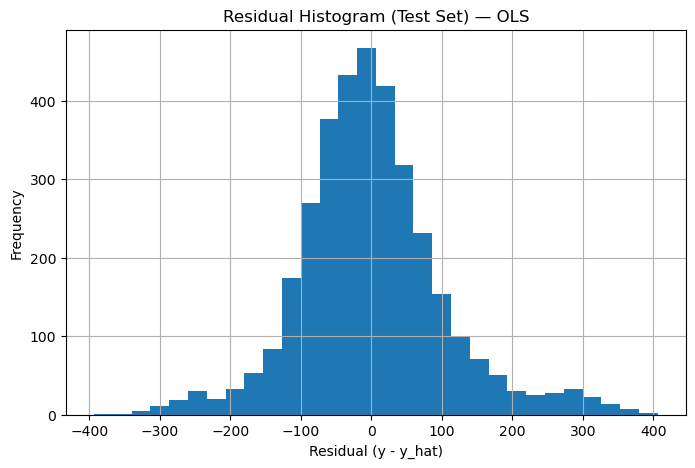

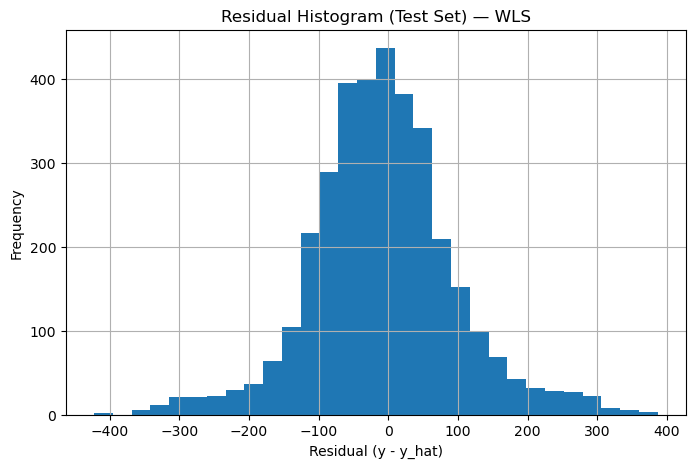

In [16]:
residuals_ols = y_test - y_test_pred
residuals_wls = y_test - y_test_pred_wls

plt.figure(figsize=(8, 5))
plt.hist(residuals_ols, bins=30)
plt.title("Residual Histogram (Test Set) — OLS")
plt.xlabel("Residual (y - y_hat)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(residuals_wls, bins=30)
plt.title("Residual Histogram (Test Set) — WLS")
plt.xlabel("Residual (y - y_hat)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


### Effect of Weighting
In Weighted Least Squares (WLS), observations with larger weights influence the fitted model more strongly.
Higher rental counts were given larger weights, so the model focuses more on predicting high-demand periods.

### OLS vs WLS Comparison 
OLS performed slightly better than WLS on the test set. OLS had a lower Test MSE and a higher Test R². This suggests that the weighting scheme used in WLS over-emphasized certain observations and slightly reduced overall generalization performance compared to treating all points equally.
